#  Importação de Bibliotecas

In [8]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix, classification_report
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# Download e Pré-processamento dos Dados

In [9]:
print("Baixando o dataset do Kaggle...")
path = kagglehub.dataset_download("williansoliveira/libras")
caminho_train = os.path.join(path, "train")
caminho_test = os.path.join(path, "test")

def carregar_imagens_da_pasta(caminho_base):
    imagens = []
    rotulos = []
    for letra in os.listdir(caminho_base):
        caminho_pasta_letra = os.path.join(caminho_base, letra)
        if os.path.isdir(caminho_pasta_letra):
            for nome_arquivo in os.listdir(caminho_pasta_letra):
                caminho_imagem = os.path.join(caminho_pasta_letra, nome_arquivo)
                imagem = cv2.imread(caminho_imagem)
                if imagem is not None:
                    imagem_redimensionada = cv2.resize(imagem, (64, 64))
                    imagens.append(imagem_redimensionada)
                    rotulos.append(letra)
                    
    X = np.array(imagens, dtype="float32") / 255.0
    y = np.array(rotulos)
    return X, y

print("Carregando dados de TREINAMENTO...")
X_train_full, y_train_full = carregar_imagens_da_pasta(caminho_train)

print("Carregando dados de TESTE...")
X_test, y_test = carregar_imagens_da_pasta(caminho_test)

# Tratamento Categórico
lb = LabelBinarizer()
y_train_full = lb.fit_transform(y_train_full)
y_test = lb.transform(y_test) 

# Divisão em Treino e Validação
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape} | Validação: {X_val.shape} | Teste: {X_test.shape}")

Baixando o dataset do Kaggle...
Carregando dados de TREINAMENTO...
Carregando dados de TESTE...
Treino: (27771, 64, 64, 3) | Validação: (6943, 64, 64, 3) | Teste: (11548, 64, 64, 3)


# Recuperar Dados

In [ ]:
print("1. Localizando os dados no computador...")
path = kagglehub.dataset_download("williansoliveira/libras")
caminho_test = os.path.join(path, "test")

print("2. Recarregando Conjunto de Teste (X_test, y_test)...")
imagens_teste = []
rotulos_teste = []

for letra in os.listdir(caminho_test):
    caminho_pasta = os.path.join(caminho_test, letra)
    if os.path.isdir(caminho_pasta):
        for nome_arquivo in os.listdir(caminho_pasta):
            imagem = cv2.imread(os.path.join(caminho_pasta, nome_arquivo))
            if imagem is not None:
                imagens_teste.append(cv2.resize(imagem, (64, 64)))
                rotulos_teste.append(letra)

# Normalização e Binarização das classes
X_test = np.array(imagens_teste, dtype="float32") / 255.0
lb = LabelBinarizer()
y_test = lb.fit_transform(np.array(rotulos_teste))
classes_nomes = lb.classes_
y_test_classes = np.argmax(y_test, axis=1) # Gabarito real para comparações

print("3. Puxando os cérebros (Modelos) do HD...")
modelo_basico = load_model('modelo_cnn_basico.keras')
modelo_transfer = load_model('modelo_transfer_libras.keras')

print("4. Puxando as memórias de treinamento (CSVs)...")
historico_df = pd.read_csv('historico_cnn_basico.csv')
# Descomente a linha abaixo se você também salvou o CSV do Transfer Learning
# historico_transfer_df = pd.read_csv('historico_transfer.csv') 

print("5. Gerando as previsões de todos os modelos (para matrizes e métricas)...")
# Previsões do Modelo Básico
y_pred_prob_basico = modelo_basico.predict(X_test)
y_pred_classes_basico = np.argmax(y_pred_prob_basico, axis=1)

# Previsões do Modelo Transfer Learning
y_pred_prob_transfer = modelo_transfer.predict(X_test)
y_pred_classes_transfer = np.argmax(y_pred_prob_transfer, axis=1)

print("\n✓ SUCESSO! Ambiente totalmente restaurado. Nenhuma análise visual foi plotada ainda.")

# Modelo 1 - CNN

## Treinamento

In [3]:
print("Construindo a CNN Básica...")

# Conta quantas classes reais o LabelBinarizer encontrou na Célula 2
num_classes = len(lb.classes_)
print(f"O modelo será treinado para classificar {num_classes} letras diferentes.")

modelo_basico = models.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), 
    
    # A MUDANÇA ESTÁ AQUI: Usamos a variável num_classes em vez de 26
    layers.Dense(num_classes, activation='softmax') 
])

modelo_basico.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Treinando o modelo...")
# Cria o "gerador" de distorções
datagen = ImageDataGenerator(
    rotation_range=20,       # Gira a imagem em até 20 graus
    width_shift_range=0.15,  # Arrasta para os lados
    height_shift_range=0.15, # Arrasta para cima/baixo
    zoom_range=0.15,         # Dá um zoom in/out de 15%
    fill_mode='nearest'      # Preenche bordas vazias
)

datagen.fit(X_train)

historico = modelo_basico.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=20,
    verbose=1
)

erro_teste, acuracia_teste = modelo_basico.evaluate(X_test, y_test)
print(f"Acurácia final CNN Básica: {acuracia_teste * 100:.2f}%")

# Salva o modelo treinado
modelo_basico.save('modelo_cnn_basico.keras')

# Salva o histórico da CNN básica
df_historico = pd.DataFrame(historico.history)
df_historico.to_csv('historico_cnn_basico.csv', index=False)

Construindo a CNN Básica...
O modelo será treinado para classificar 21 letras diferentes.
Treinando o modelo...


c:\Users\yujif\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.2685 - loss: 2.2415 - val_accuracy: 0.7510 - val_loss: 0.8950
Epoch 2/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.5336 - loss: 1.3112 - val_accuracy: 0.8020 - val_loss: 0.5556
Epoch 3/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.6316 - loss: 1.0288 - val_accuracy: 0.9043 - val_loss: 0.3386
Epoch 4/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.6829 - loss: 0.8729 - val_accuracy: 0.9187 - val_loss: 0.2774
Epoch 5/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.7251 - loss: 0.7673 - val_accuracy: 0.9537 - val_loss: 0.2161
Epoch 6/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.7571 - loss: 0.6779 - val_accuracy: 0.9506 - val_loss: 0.1758
Epoch 7/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.7689 - loss: 0.6340 - val_accuracy: 0.9280 - val_loss: 0.2081
Epoch 8/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.7929 - loss: 0.5744 - 

## Avaliação dos Resultados (CNN)

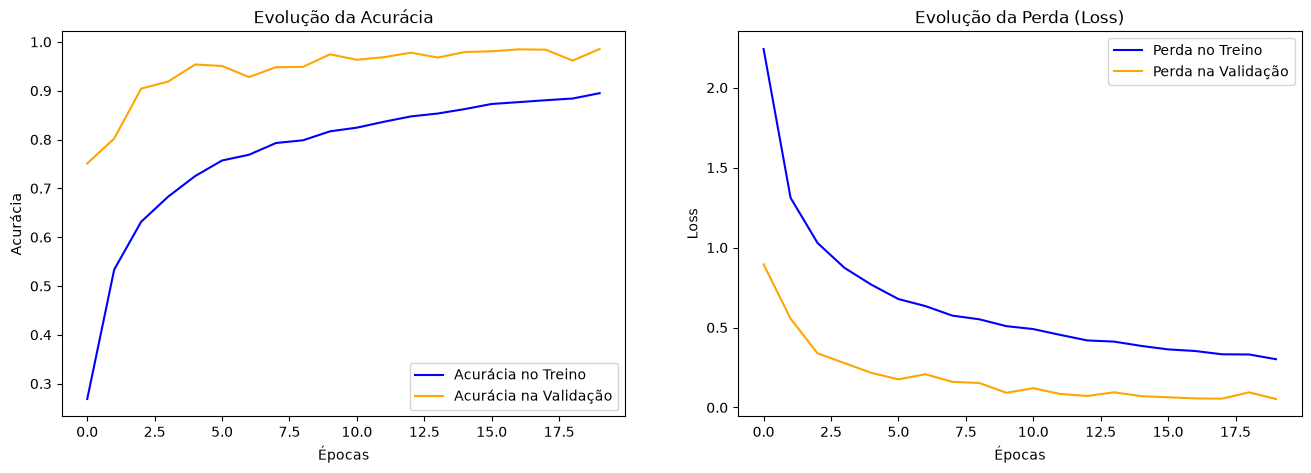

In [4]:
# 1. Gráficos de Treinamento (Acurácia e Perda/Loss)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de Acurácia (Desenhando no ax[0] - Esquerda)
ax[0].plot(historico.history['accuracy'], label='Acurácia no Treino', color='blue')
ax[0].plot(historico.history['val_accuracy'], label='Acurácia na Validação', color='orange')
ax[0].set_title('Evolução da Acurácia')
ax[0].set_xlabel('Épocas')
ax[0].set_ylabel('Acurácia')
ax[0].legend()

# Gráfico de Perda/Loss (Desenhando no ax[1] - Direita)
ax[1].plot(historico.history['loss'], label='Perda no Treino', color='blue')
ax[1].plot(historico.history['val_loss'], label='Perda na Validação', color='orange')
ax[1].set_title('Evolução da Perda (Loss)')
ax[1].set_xlabel('Épocas')
ax[1].set_ylabel('Loss')
ax[1].legend()

# Exibe os gráficos
plt.show()

## Grad-CAM

In [5]:
print("Gerando Mapa de Calor (Grad-CAM)...")

ultima_camada_conv_nome = None

# Lemos as camadas de trás para frente até achar a primeira Convolução
for layer in reversed(modelo_basico.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        ultima_camada_conv_nome = layer.name
        break

if ultima_camada_conv_nome is None:
    raise ValueError("Não foi encontrada nenhuma camada Conv2D no modelo!")

print(f"Camada alvo encontrada: {ultima_camada_conv_nome}")

def gerar_grad_cam(img_array, modelo, nome_ultima_camada):
    # Convertemos o array em um tensor do TensorFlow
    img_tensor = tf.cast(img_array, tf.float32)
    
    with tf.GradientTape() as tape:
        x = img_tensor
        ultima_camada_output = None
        
        for layer in modelo.layers:
            x = layer(x)
            if layer.name == nome_ultima_camada:
                # Capturamos a saída da convolução alvo
                ultima_camada_output = x
        
        # No final do loop, 'x' conterá a saída da última camada (predições)
        preds = x
        # Pega o índice da classe com maior probabilidade
        indice_classe_predita = tf.argmax(preds[0])
        classe_canal = preds[:, indice_classe_predita]

    # Calcula os gradientes da classe predita em relação à saída da camada convolucional
    grads = tape.gradient(classe_canal, ultima_camada_output)
    
    # Global Average Pooling (GAP) para achar a importância de cada canal
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Pegamos a saída da camada para a primeira imagem do lote
    camada_output_valores = ultima_camada_output[0]
    
    # Multiplica cada canal por sua respectiva importância (produto de matrizes)
    heatmap = camada_output_valores @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Aplica a função ReLU manual (descarta valores negativos)
    heatmap = tf.maximum(heatmap, 0)
    
    # Normalização segura para evitar divisão por zero
    max_val = tf.math.reduce_max(heatmap)
    if max_val == 0:
        max_val = 1e-10
    heatmap = heatmap / max_val
    
    return heatmap.numpy()

# 2. Selecionando uma imagem de teste
imagem_teste = X_test[0]
letra_real = lb.classes_[np.argmax(y_test[0])] # Pega a letra correta dessa imagem

# O TensorFlow exige um "lote" (batch), então expandimos a dimensão da imagem
imagem_lote = np.expand_dims(imagem_teste, axis=0)

# Gerando o mapa de calor base
mapa_calor = gerar_grad_cam(imagem_lote, modelo_basico, ultima_camada_conv_nome)

# 3. Sobrepondo o mapa na imagem original
# Redimensiona o mapa de calor de volta para o tamanho da foto original (Largura, Altura)
mapa_calor_redimensionado = cv2.resize(mapa_calor, (imagem_teste.shape[1], imagem_teste.shape[0]))

# Converte o mapa para um formato de cores de 8 bits (0-255)
mapa_calor_colorido = np.uint8(255 * mapa_calor_redimensionado)
mapa_calor_colorido = cv2.applyColorMap(mapa_calor_colorido, cv2.COLORMAP_JET)

# Tratamento para garantir que a imagem original esteja no formato correto de cores
if len(imagem_teste.shape) == 2 or imagem_teste.shape[2] == 1:
    imagem_original_rgb = cv2.cvtColor(np.uint8(255 * imagem_teste), cv2.COLOR_GRAY2RGB)
else:
    imagem_original_rgb = cv2.cvtColor(np.uint8(255 * imagem_teste), cv2.COLOR_BGR2RGB)

# Mistura a imagem original com o mapa de calor (40% de transparência no mapa)
imagem_sobreposta = cv2.addWeighted(imagem_original_rgb, 0.6, mapa_calor_colorido, 0.4, 0)

# 4. Cria a pasta para salvar as imagens (se ela não existir)
pasta_saida = "resultados_gradcam_cnn"
os.makedirs(pasta_saida, exist_ok=True)

print(f"Gerando e salvando os mapas de calor na pasta '{pasta_saida}'...")

# 5. Itera sobre cada letra do alfabeto que a IA aprendeu
classes_nomes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'Y']
y_test_classes = np.argmax(y_test, axis=1)

for i, letra in enumerate(classes_nomes):
    # Encontra os índices de todas as imagens no X_test que pertencem a essa letra
    # O [0] extrai o array real de dentro da tupla que o np.where retorna
    indices_letra = np.where(y_test_classes == i)[0] 
    
    # Se por acaso não tivermos nenhuma imagem dessa letra no teste, pulamos
    if len(indices_letra) == 0:
        continue 
        
    # Pegamos apenas a PRIMEIRA imagem dessa letra para o nosso exemplo
    idx = indices_letra[0]
    imagem_teste = X_test[idx]
    
    # Prepara a imagem adicionando a dimensão do lote (batch)
    imagem_lote = np.expand_dims(imagem_teste, axis=0)
    
    # Roda a função para gerar o mapa
    mapa_calor = gerar_grad_cam(imagem_lote, modelo_basico, ultima_camada_conv_nome)
    
    # 3. Sobreposição de Cores
    # Redimensiona o mapa de calor de volta para o tamanho da foto (Largura, Altura)
    mapa_calor_redimensionado = cv2.resize(mapa_calor, (imagem_teste.shape[1], imagem_teste.shape[0]))
    
    # Aplica o mapa de cores JET
    mapa_calor_colorido = np.uint8(255 * mapa_calor_redimensionado)
    mapa_calor_colorido = cv2.applyColorMap(mapa_calor_colorido, cv2.COLORMAP_JET)
    
    # Ajusta as cores da imagem original para exibir no Matplotlib
    # Verificação de segurança caso a imagem seja em escala de cinza
    if len(imagem_teste.shape) == 2 or imagem_teste.shape[2] == 1:
        imagem_original_rgb = cv2.cvtColor(np.uint8(255 * imagem_teste), cv2.COLOR_GRAY2RGB)
    else:
        imagem_original_rgb = cv2.cvtColor(np.uint8(255 * imagem_teste), cv2.COLOR_BGR2RGB)
    
    # Funde as duas imagens
    imagem_sobreposta = cv2.addWeighted(imagem_original_rgb, 0.6, mapa_calor_colorido, 0.4, 0)
    
    # 4. Criação do Gráfico
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(imagem_original_rgb)
    ax[0].set_title(f'Original: Letra {letra}')
    ax[0].axis('off')
    
    # Uso do cmap viridis para visualizar o mapa bruto melhor
    ax[1].imshow(mapa_calor, cmap='viridis')
    ax[1].set_title('Mapa de Características')
    ax[1].axis('off')
    
    ax[2].imshow(imagem_sobreposta)
    ax[2].set_title('Grad-CAM (Atenção)')
    ax[2].axis('off')
    
    # 5. Salvamento no disco
    caminho_arquivo = os.path.join(pasta_saida, f"gradcam_cnn_{letra}.png")
    
    # Salva a figura eliminando as bordas em branco extras
    plt.savefig(caminho_arquivo, bbox_inches='tight')
    
    # Fecha a figura para limpar a RAM e não poluir a tela do Notebook
    plt.close(fig) 
    
    print(f"✓ Salvo: {caminho_arquivo}")

print("\nProcesso concluído com sucesso!")

Gerando Mapa de Calor (Grad-CAM)...
Camada alvo encontrada: conv2d_1
Gerando e salvando os mapas de calor na pasta 'resultados_gradcam_cnn'...
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_A.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_B.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_C.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_D.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_E.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_F.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_G.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_I.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_L.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_M.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_N.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_O.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_P.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_Q.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_R.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_S.png
✓ Salvo: resultados_gradcam_cnn\gradcam_cnn_T.png
✓ Salvo

# Modelo 2 - Transfer Learning

## Treinamento

In [13]:
print("Construindo o Modelo de Transfer Learning (MobileNet)...")

# 1. LÊ A QUANTIDADE DE CLASSES DIRETAMENTE DO SEU DATASET (EVITA O ERRO DE SHAPE)
quantidade_classes = y_train.shape[1]
print(f"Atenção: O modelo identificou {quantidade_classes} classes no seu dataset.")

# Carrega o MobileNet
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
base_model.trainable = False # Congela os pesos originais

modelo_transfer = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5), # Desliga 50% das conexões (evita olhar para o fundo)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Desliga mais 30% antes da decisão final
    
    # 2. CRIA EXATAMENTE A QUANTIDADE DE NEURÔNIOS QUE SEU DATASET EXIGE
    layers.Dense(quantidade_classes, activation='softmax')
])

modelo_transfer.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Treinando o modelo de Transfer Learning...")
# Cria o "gerador" de distorções
datagen = ImageDataGenerator(
    rotation_range=20,       # Gira a imagem em até 20 graus
    width_shift_range=0.15,  # Arrasta para os lados
    height_shift_range=0.15, # Arrasta para cima/baixo
    zoom_range=0.15,         # Dá um zoom in/out de 15%
    fill_mode='nearest'      # Preenche bordas vazias
)

datagen.fit(X_train)

historico_transfer = modelo_transfer.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=25,
    verbose=1
)

erro_teste_t, acuracia_teste_t = modelo_transfer.evaluate(X_test, y_test)
print(f"Acurácia final Transfer Learning: {acuracia_teste_t * 100:.2f}%")

# Salva o modelo treinado
modelo_transfer.save('modelo_transfer_libras.keras')

# Salva o histórico da CNN
df_historico_transfer = pd.DataFrame(historico_transfer.history)
df_historico_transfer.to_csv('historico_transfer.csv', index=False)

Construindo o Modelo de Transfer Learning (MobileNet)...
Atenção: O modelo identificou 21 classes no seu dataset.


C:\Users\yujif\AppData\Local\Temp\ipykernel_17924\1426302696.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(64, 64, 3))


Treinando o modelo de Transfer Learning...


KeyboardInterrupt: 

## Avaliação dos Resultados (Transfer)

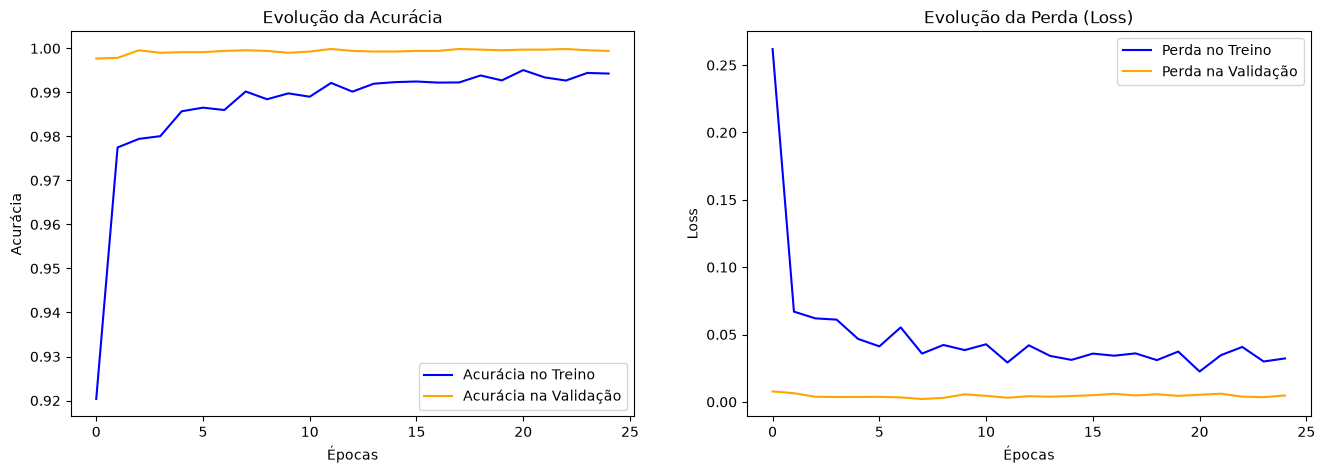

In [26]:
# 1. Gráficos de Treinamento (Acurácia e Perda/Loss)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de Acurácia (Desenhando no ax[0] - Esquerda)
ax[0].plot(historico_transfer.history['accuracy'], label='Acurácia no Treino', color='blue')
ax[0].plot(historico_transfer.history['val_accuracy'], label='Acurácia na Validação', color='orange')
ax[0].set_title('Evolução da Acurácia')
ax[0].set_xlabel('Épocas')
ax[0].set_ylabel('Acurácia')
ax[0].legend()

# Gráfico de Perda/Loss (Desenhando no ax[1] - Direita)
ax[1].plot(historico_transfer.history['loss'], label='Perda no Treino', color='blue')
ax[1].plot(historico_transfer.history['val_loss'], label='Perda na Validação', color='orange')
ax[1].set_title('Evolução da Perda (Loss)')
ax[1].set_xlabel('Épocas')
ax[1].set_ylabel('Loss')
ax[1].legend()

# Exibe os gráficos
plt.show()

## Grad-CAM

In [29]:
print("Gerando Mapa de Calor (Grad-CAM) para Transfer Learning...")

# --- 1. Garante que a entrada do modelo está definida ---
# Se suas imagens tiverem outro tamanho, ajuste o (64, 64, 3)
modelo_transfer.build(input_shape=(None, 64, 64, 3)) 

# --- 2. Busca Inteligente da Camada Conv2D ---
modelo_base = None
ultima_camada_conv_nome = None

# Passo A: Verifica se existe um "Modelo Base" encapsulado na rede
for layer in modelo_transfer.layers:
    if isinstance(layer, tf.keras.Model):
        modelo_base = layer
        break

# Passo B: Procura a Conv2D no local correto
if modelo_base is not None:
    print(f"Modelo base detectado: '{modelo_base.name}'. Procurando camadas internas...")
    for layer in reversed(modelo_base.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            ultima_camada_conv_nome = layer.name
            break
else:
    print("Nenhum modelo base detectado. Procurando nas camadas principais...")
    for layer in reversed(modelo_transfer.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            ultima_camada_conv_nome = layer.name
            break

if ultima_camada_conv_nome is None:
    raise ValueError("Não foi encontrada nenhuma camada Conv2D no modelo!")

print(f"Camada alvo encontrada: {ultima_camada_conv_nome}")

# --- 3. Função Grad-CAM Preparada para Transfer Learning ---
def gerar_grad_cam_tl(img_array, modelo_principal, modelo_interno, nome_ultima_camada):
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        if modelo_interno is not None:
            # --- ESTRATÉGIA PARA TRANSFER LEARNING (Modelo Aninhado) ---
            # O modelo interno (ex: VGG, MobileNet) sempre tem um input válido.
            # Criamos um extrator apenas para ele.
            extrator_base = tf.keras.models.Model(
                inputs=modelo_interno.input,
                outputs=[modelo_interno.get_layer(nome_ultima_camada).output, modelo_interno.output]
            )
            # Passamos a imagem pelo modelo base
            ultima_camada_output, x = extrator_base(img_tensor)
            
            # Agora passamos o resultado (x) pelas camadas finais do modelo principal
            for layer in modelo_principal.layers:
                # Pula o modelo base, pois já processamos ele
                if layer.name == modelo_interno.name:
                    continue
                x = layer(x)
        else:
            # --- ESTRATÉGIA PARA MODELO SIMPLES (Caso não haja modelo aninhado) ---
            x = img_tensor
            ultima_camada_output = None
            for layer in modelo_principal.layers:
                x = layer(x)
                if layer.name == nome_ultima_camada:
                    ultima_camada_output = x

        # A variável 'x' agora contém a predição final
        preds = x
        indice_classe_predita = tf.argmax(preds[0])
        classe_canal = preds[:, indice_classe_predita]

    # Calcula os gradientes (matemática do Grad-CAM)
    grads = tape.gradient(classe_canal, ultima_camada_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    camada_output_valores = ultima_camada_output[0]
    heatmap = camada_output_valores @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    
    # Normalização segura
    max_val = tf.math.reduce_max(heatmap)
    if max_val == 0:
        max_val = 1e-10
    heatmap = heatmap / max_val
    
    return heatmap.numpy()

# --- 4. Preparação e Salvamento ---
pasta_saida = "resultados_gradcam_transfer"
os.makedirs(pasta_saida, exist_ok=True)
print(f"\nGerando e salvando os mapas de calor na pasta '{pasta_saida}'...")

classes_nomes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'Y']
y_test_classes = np.argmax(y_test, axis=1)

for i, letra in enumerate(classes_nomes):
    indices_letra = np.where(y_test_classes == i)[0] 
    
    if len(indices_letra) == 0:
        continue 
        
    idx = indices_letra[0]
    imagem_teste = X_test[idx]
    imagem_lote = np.expand_dims(imagem_teste, axis=0)
    
    # Roda a nova função passando o modelo base junto!
    mapa_calor = gerar_grad_cam_tl(imagem_lote, modelo_transfer, modelo_base, ultima_camada_conv_nome)
    
    # Redimensionamento
    mapa_calor_redimensionado = cv2.resize(mapa_calor, (imagem_teste.shape[1], imagem_teste.shape[0]))
    
    # Cores
    mapa_calor_colorido = np.uint8(255 * mapa_calor_redimensionado)
    mapa_calor_colorido = cv2.applyColorMap(mapa_calor_colorido, cv2.COLORMAP_JET)
    
    if len(imagem_teste.shape) == 2 or imagem_teste.shape[2] == 1:
        imagem_original_rgb = cv2.cvtColor(np.uint8(255 * imagem_teste), cv2.COLOR_GRAY2RGB)
    else:
        imagem_original_rgb = cv2.cvtColor(np.uint8(255 * imagem_teste), cv2.COLOR_BGR2RGB)
    
    imagem_sobreposta = cv2.addWeighted(imagem_original_rgb, 0.6, mapa_calor_colorido, 0.4, 0)
    
    # Gráficos
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(imagem_original_rgb)
    ax[0].set_title(f'Original: Letra {letra}')
    ax[0].axis('off')
    
    ax[1].imshow(mapa_calor, cmap='viridis')
    ax[1].set_title('Mapa de Características')
    ax[1].axis('off')
    
    ax[2].imshow(imagem_sobreposta)
    ax[2].set_title('Grad-CAM (Atenção)')
    ax[2].axis('off')
    
    # Salva e limpa a memória
    caminho_arquivo = os.path.join(pasta_saida, f"gradcam_transfer_{letra}.png")
    plt.savefig(caminho_arquivo, bbox_inches='tight')
    plt.close(fig) 
    
    print(f"✓ Salvo: {caminho_arquivo}")

print("\nProcesso concluído com sucesso!")

Gerando Mapa de Calor (Grad-CAM) para Transfer Learning...
Modelo base detectado: 'mobilenet_1.00_224'. Procurando camadas internas...
Camada alvo encontrada: conv_pw_13

Gerando e salvando os mapas de calor na pasta 'resultados_gradcam_transfer'...
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_A.png
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_B.png
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_C.png
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_D.png
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_E.png
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_F.png
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_G.png
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_I.png
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_L.png
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_M.png
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_N.png
✓ Salvo: resultados_gradcam_transfer\gradcam_transfer_O.png
✓ Salvo: resultados_gradcam_tr